# Does host vocabulary *start* newcomer uptake or *grow* it? (K1 / INFERENCE demo)

This notebook is a runnable demo of the **POST-CONFIRMATION EXPLORATORY** evaluation `eval.py`. It examines the
confirmed **D2 host-entry effect**: a concept enters a host subfield, and `A_cont` measures how much of its entry
vocabulary leans towards the host. The outcome is **newcomer uptake** `Y_strict`, the number of new host-field
authors who later use the concept.

`eval.py` is an orchestrator. It runs six stage scripts in order: `k/k_freeze.py` (gates and frozen spec),
`k/k_run.py --synthetic` (smoke test), `k/k_run.py` (K1, K3 and INFERENCE), `audit/audit_k.py`, `k/report.py` and
`audit/audit_placebo.py`. The stage scripts share the helper library `k/k_lib.py` and the vendored D2 estimators
(`d2/src/ppml.py`, `d2/src/models.py`). In this notebook, **the orchestrator calls these functions directly
instead of launching subprocesses**. The code in each cell is copied from those files.

**What runs here** (on the **held-out fold**, which was the confirmatory fold: 93 concepts and 1,097 host-entry events)
* **K1: which margin?** The total effect is split into
  * an **extensive margin**: does uptake *start* at all (`Any = 1[Y>=1]`), estimated with an LPM, an FE-logit and a log-link PPML;
  * an **intensive margin**: how much uptake grows *given* that it starts (PPML on `Y>=1`).

  K1 also includes a threshold ladder, a concept-cluster-bootstrap decomposition and IVW pooling.
* **INFERENCE (size-correct p-values):** the randomization-t test with within-concept shuffles of `A_cont`,
  Freedman-Lane, and the Webb and Rademacher wild cluster score bootstraps.

**What is only shown from the full run:** SCREEN and MeSH (the other two folds), the K3 field-boundary test (which
needs the pooled screen and held-out samples), and the audits. Their numbers are in `data["reference"]` and appear in
the final summary.

Full-run headline: the extensive LPM IVW is **+6.43 pp/SD [4.76, 8.11]**, the intensive IVW IRR/SD is **1.183**, and
the K1 verdict is **BOTH**. The held-out randomization-t p is **0.023**.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# ---- eval.py imports (original)
import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# ---- k/k_lib.py imports (original)
import hashlib
import json
import math

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):  # one BLAS thread per worker process
    os.environ[_v] = "1"
import resource

import numpy as np
import pandas as pd
from scipy import sparse, stats
from scipy.sparse.linalg import splu

# ---- notebook additions: module-like namespaces for the vendored code, plotting
import types
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-5/evaluation-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f'{data["metadata"]["n_concepts"]} concepts, {data["metadata"]["n_events"]} events; '
      f'frozen spec sha256 {data["metadata"]["spec_sha256"][:16]}...')

Held-out fold of the frozen D2 event table (one example = one concept with its host-entry events), plus reference numbers from the full K1/K3/INFERENCE run.
93 concepts, 1097 events; frozen spec sha256 2435f909758bfab4...


## Configuration

These are the tunable parameters. The full run takes its draw counts from the frozen spec `k13_spec.json`. The
demo runs **sequentially** in one process and still uses the **original counts** on the held-out fold, which takes
about 2.5 minutes on a 2-CPU machine. The original value is noted next to each parameter. To make the notebook
faster, lower `BOOT_DRAWS` or `RAND_DRAWS`. The point estimates and CRV1 standard errors do not depend on these
counts. Only the Monte-Carlo p-values and the bootstrap intervals get coarser.

In [5]:
N_CONCEPTS = 93          # held-out concepts to use (all 93 = the frozen held-out sample; original: 93)
BOOT_DRAWS = 1000        # K1 concept-cluster bootstrap draws per fold          (original: 1000)
RAND_DRAWS = 2000        # randomization-t / Freedman-Lane draws per fold       (original: 2000)
WILD_REPS = 9999         # Webb 6-point wild cluster score bootstrap draws      (original: 9999)
RADEMACHER_REPS = 999    # Rademacher wild check draws                          (original: 999)
OUT_DIR = "results_demo" # where the K1 / INFERENCE CSV + JSON outputs are written

## 1. The orchestrator (`eval.py`)

This cell is the logger setup and stage table from `eval.py`. The stage table maps each stage to the script it runs.
In the original, `run(stage)` starts each script as a subprocess. That cannot work in Colab, so the stage loop at
the end of this notebook calls the equivalent in-notebook functions (`run_k1`, `run_inference`) instead.

In [6]:
WS = Path.cwd()  # original: Path(__file__).resolve().parent
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

STAGES = {"freeze": ["k/k_freeze.py", "--reps", "300"], "smoke": ["k/k_run.py", "--synthetic"],
          "run": ["k/k_run.py", "--stage", "all"], "audit": ["audit/audit_k.py"], "report": ["k/report.py"],
          "placebo": ["audit/audit_placebo.py"]}

## 2. Vendored D2 estimator: `d2/src/ppml.py` (byte-exact in the artifact)

This is PPML (Poisson pseudo-maximum likelihood) with high-dimensional fixed effects. It is fitted by IRLS. At each
iteration, an **exact weighted projection** removes the FE space: a sparse LU solves `(D'WD + eps I) c = D'W M`.
Standard errors are CRV1, clustered by concept, with pyfixest's `fixef_k='nested'` small-sample factor. `_prune`
iteratively drops singleton FE levels and levels whose outcome is all zero. The functions are wrapped in a
`ppml` namespace so that the `k_lib` code below can call `ppml.fit(...)` unchanged.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


# notebook: expose as the `ppml` module that k_lib imports
ppml = types.SimpleNamespace(_prune=_prune, _demean=_demean, pd_nunique_per_level=pd_nunique_per_level, fit=fit,
                             wild_score_test=wild_score_test)

## 3. Vendored D2 sample definition: `d2/src/models.py` (excerpt)

`primary_sample` is the frozen event-sample filter: main arm, the requested fold, 5+ keywords, the MAIN population
and complete covariates. It also builds the fixed-effect columns. The **co-primary** specification used throughout K1
is `concept + e + d`, meaning concept FE, entry-year FE and host-subfield FE (`cfe`, `efe`, `dfe`). The offset is
`log(n_entry_papers)`. The demo rows have already been filtered this way, so re-applying the filter keeps all of them.

In [8]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]


def primary_sample(df: pd.DataFrame, pop: str = "MAIN", fold: str = "screen") -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df[pop]].copy()
    need = [A_VAR, CT_VAR] + EVENT_CONTROLS + SECONDARY_EXTRA
    s = s.dropna(subset=[c for c in need if c in s.columns])
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s.reset_index(drop=True)


# notebook: expose as the `models` module that k_lib imports
models = types.SimpleNamespace(EVENT_CONTROLS=EVENT_CONTROLS, SECONDARY_EXTRA=SECONDARY_EXTRA,
                               primary_sample=primary_sample)

## 4. Shared library `k/k_lib.py`: constants, utilities and the fold loader

`load_fold` is the only function changed in substance. It now builds the held-out event table from the loaded `data`
(one example per concept) instead of reading `inputs/g_features_heldout_coprimary.parquet`. `add_outcomes` defines
the K1 outcomes:
* `Any = 1[Y_strict >= 1]`, the extensive margin;
* the ladder thresholds `Y_ge3` and `Y_ge5`;
* `log_nep = log(n_entry_papers)`, which the binary models use as a regressor, because an offset has no meaning for a probability.

In [9]:
RESULTS = WS / OUT_DIR   # original: WS / "results"
LOGS = WS / "logs"
for _d in (RESULTS, LOGS):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 20261001
CTRL2 = models.EVENT_CONTROLS + models.SECONDARY_EXTRA
FOLDS = ("SCREEN", "HELDOUT", "MESH")
FIELD_OF_GROUP = {31: "Physics/Astro", 17: "CS"}
GROUPS = ("Physics/Astro", "CS", "other")


# ---------------------------------------------------------------------------------------------------- utilities
def dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=1, default=_json_default))


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return str(o)


def clean(x):
    """Recursively replace NaN / inf with None so the JSON is strict."""
    if isinstance(x, dict):
        return {k: clean(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(v) for v in x]
    if isinstance(x, (float, np.floating)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.bool_):
        return bool(x)
    return x


def rel(p: Path | str) -> str:
    """Path relative to the working directory for source columns; never an absolute server path."""
    p = Path(p).resolve()
    root = WS  # original: WS.parents[3] (the run root)
    try:
        return str(p.relative_to(root))
    except ValueError:
        return str(p)


# ---------------------------------------------------------------------------------------------------- loaders
def add_outcomes(s: pd.DataFrame) -> pd.DataFrame:
    s = s.copy()
    y = s["Y_strict"].astype(float)
    s["Any"] = (y >= 1).astype(float)
    s["Y_ge3"] = (y >= 3).astype(float)
    s["Y_ge5"] = (y >= 5).astype(float)
    s["EST_bin"] = s["EST_bin"].astype(float)
    s["log_nep"] = np.log(s["n_entry_papers"].astype(float))
    return s


def load_fold(fold: str) -> pd.DataFrame:
    """Frozen per-event sample of a fold with the co-primary FE columns (cfe/efe/dfe, cxe/dxe) and offset.
    Notebook: only HELDOUT is in mini_demo_data.json; its events are rebuilt from data["examples"] (one per concept)
    instead of pd.read_parquet(INPUTS / "g_features_heldout_coprimary.parquet")."""
    if fold == "HELDOUT":
        rows = [dict(ev, concept_id=ex["concept_id"]) for ex in data["examples"][:N_CONCEPTS] for ev in ex["events"]]
        s = models.primary_sample(pd.DataFrame(rows), fold="heldout")
    else:
        raise ValueError(f"{fold}: not in the demo data (see data['reference'] for the full-run numbers)")
    s = add_outcomes(s)
    s["fold"] = fold
    return s.reset_index(drop=True)


def controls(fold: str) -> list[str]:
    return CTRL2  # original: mesh_controls() if fold == "MESH" else CTRL2 (MESH is not in the demo data)


def fe_cols_for(fe: str) -> list[str]:
    return {"coprimary": ["cfe", "efe", "dfe"], "primary": ["cxe", "dxe"], "k3": ["cfe", "fxe", "dfe"]}[fe]

## 5. `k_lib`: FE pruning, the HDFE linear probability model (LPM) and the FE-logit

* **`LPM`** fits OLS with high-dimensional fixed effects by exact projection. The retained sample (after iterated
  singleton pruning) depends only on the FE structure, so the projector is **factorised once** and reused for every
  outcome and every permuted regressor. The randomization test depends on this.
* **`lpm_row`** reports the extensive-margin effect in **percentage points per SD of `A_cont`**, with a t(G-1) CI
  and the base rate.
* **`logit_fe_fit`** is an unconditional FE logit fitted by IRLS with a weighted within-transformation. Concepts
  whose outcome is all 0 or all 1 are pruned.

In [10]:
# ---------------------------------------------------------------------------------------------------- pruning
def prune_singletons(fes: list[np.ndarray]) -> np.ndarray:
    """Iterated singleton pruning (LPM / binary models: no separation rule)."""
    keep = np.ones(len(fes[0]), bool)
    for _ in range(100):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            drop = keep & (cnt[f] <= 1)
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def prune_binary_separation(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iterated pruning for FE-logit: singleton levels and levels whose outcome is all-0 or all-1."""
    keep = np.ones(len(y), bool)
    for _ in range(100):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0) | (sy >= cnt)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _relabel(fes: list[np.ndarray], keep: np.ndarray) -> list[np.ndarray]:
    return [np.unique(f[keep], return_inverse=True)[1] for f in fes]


def _dummy(fes: list[np.ndarray]) -> sparse.csc_matrix:
    n = len(fes[0])
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    return sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))


def ssc_adj(n: int, kx: int, fes: list[np.ndarray], g: np.ndarray) -> float:
    """pyfixest CRV1 small-sample factor with fixef_k='nested' (identical rule to vendored ppml.fit)."""
    G = int(g.max()) + 1
    k_fe = 0
    for f in fes:
        if not (ppml.pd_nunique_per_level(f, g) <= 1):
            k_fe += int(f.max())
    k = kx + k_fe + (1 if k_fe else 0)
    return G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0


# ---------------------------------------------------------------------------------------------------- LPM
class LPM:
    """OLS with HDFE by exact projection. The retained sample (iterated singleton pruning) depends only on the FE
    structure, so the projector is factorised ONCE and reused for every outcome / permuted regressor."""

    def __init__(self, fes: list[np.ndarray], cluster: np.ndarray):
        self.keep = prune_singletons(fes)
        self.fes = _relabel(fes, self.keep)
        self.D = _dummy(self.fes)
        A = sparse.csc_matrix(self.D.T @ self.D) + sparse.identity(self.D.shape[1], format="csc") * 1e-9
        self.lu = splu(A)
        self.g = np.unique(cluster[self.keep], return_inverse=True)[1]
        self.G = int(self.g.max()) + 1
        self.n = int(self.keep.sum())

    def __getstate__(self):  # SuperLU is not picklable: refactorise in the worker
        st = dict(self.__dict__)
        st.pop("lu", None)
        return st

    def __setstate__(self, st):
        self.__dict__.update(st)
        A = sparse.csc_matrix(self.D.T @ self.D) + sparse.identity(self.D.shape[1], format="csc") * 1e-9
        self.lu = splu(A)

    def demean(self, M: np.ndarray) -> np.ndarray:
        M = np.asarray(M, float)
        return M - self.D @ self.lu.solve(np.asarray(self.D.T @ M))

    def fit(self, y: np.ndarray, X: np.ndarray, Xt: np.ndarray | None = None) -> dict:
        """y, X on the FULL input sample (keep applied here); Xt optional pre-demeaned X on the kept sample."""
        yk = np.asarray(y, float)[self.keep]
        if Xt is None:
            Xt = self.demean(np.asarray(X, float)[self.keep])
        yt = self.demean(yk[:, None])[:, 0]
        XtX = Xt.T @ Xt
        beta = np.linalg.solve(XtX, Xt.T @ yt)
        e = yt - Xt @ beta
        Hi = np.linalg.inv(XtX)
        S = np.zeros((self.G, Xt.shape[1]))
        np.add.at(S, self.g, Xt * e[:, None])
        adj = ssc_adj(self.n, Xt.shape[1], self.fes, self.g)
        V = adj * Hi @ (S.T @ S) @ Hi
        return {"coef": beta, "se": np.sqrt(np.diag(V)), "V": V, "n": self.n, "G": self.G, "resid": e, "Xt": Xt,
                "yt": yt}


def lpm_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> dict:
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    r = eng.fit(s[y].to_numpy(float), s[xvars].to_numpy(float))
    j = xvars.index(target)
    b, se = float(r["coef"][j]), float(r["se"][j])
    sd = float(s.loc[eng.keep, target].std())
    G = r["G"]
    tq = stats.t.ppf(0.975, G - 1)
    base = float(s.loc[eng.keep, y].mean())
    return {"model": "LPM", "y": y, "fe": fe, "b": b, "se": se, "t": b / se, "p_crv1": float(2 * stats.t.sf(abs(b / se), G - 1)),
            "sd": sd, "pp_per_sd": 100 * b * sd, "ci_pp_per_sd": [100 * (b - tq * se) * sd, 100 * (b + tq * se) * sd],
            "base_rate": base, "rel_to_base": (b * sd) / base if base > 0 else None,
            "N": r["n"], "N_input": int(len(s)), "G": G, "retained_share": r["n"] / len(s)}


# ---------------------------------------------------------------------------------------------------- FE logit
def logit_fe_fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], cluster: np.ndarray, maxit: int = 200,
                 tol: float = 1e-10) -> dict | None:
    """Unconditional FE logit by IRLS with a weighted within-transformation (exact sparse projection, as vendored
    ppml.fit does for the log link). FE levels with all-0 / all-1 outcomes and singletons are pruned (iterated)."""
    keep = prune_binary_separation(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    yk, Xk, cl = y[keep].astype(float), X[keep].astype(float), cluster[keep]
    fk = _relabel(fes, keep)
    p = np.clip(0.5 * np.ones_like(yk) * 0 + (yk + 0.5) / 2, 0.05, 0.95)
    eta = np.log(p / (1 - p))
    dev_old = np.inf
    beta = np.zeros(Xk.shape[1])
    for _ in range(maxit):
        w = p * (1 - p)
        z = eta + (yk - p) / w
        M = ppml._demean(np.column_stack([z, Xk]), w, fk)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * w[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = np.clip(z - resid, -30, 30)
        p = 1 / (1 + np.exp(-eta))
        p = np.clip(p, 1e-12, 1 - 1e-12)
        dev = -2 * np.sum(yk * np.log(p) + (1 - yk) * np.log(1 - p))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    w = p * (1 - p)
    Xt = ppml._demean(Xk, w, fk)
    Hi = np.linalg.inv(Xt.T @ (Xt * w[:, None]))
    g = np.unique(cl, return_inverse=True)[1]
    G = int(g.max()) + 1
    S = np.zeros((G, Xk.shape[1]))
    np.add.at(S, g, Xt * (yk - p)[:, None])
    adj = ssc_adj(len(yk), Xk.shape[1], fk, g)
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(len(yk)), "G": G, "keep": keep}


def logit_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> dict:
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    r = logit_fe_fit(s[y].to_numpy(float), s[xvars].to_numpy(float), fes, s.concept_id.to_numpy())
    if r is None:
        return {"model": "FE-logit", "y": y, "fe": fe, "status": "not estimable (too few events after pruning)"}
    j = xvars.index(target)
    b, se = float(r["coef"][j]), float(r["se"][j])
    sd = float(s.loc[r["keep"], target].std())
    tq = stats.t.ppf(0.975, r["G"] - 1)
    conc_all = s.concept_id.nunique()
    conc_kept = s.loc[r["keep"], "concept_id"].nunique()
    return {"model": "FE-logit", "y": y, "fe": fe, "b": b, "se": se, "t": b / se,
            "p_crv1": float(2 * stats.t.sf(abs(b / se), r["G"] - 1)), "sd": sd, "or_per_sd": math.exp(b * sd),
            "ci_or_per_sd": [math.exp((b - tq * se) * sd), math.exp((b + tq * se) * sd)], "N": r["n"],
            "N_input": int(len(s)), "G": r["G"], "concepts_dropped_all0_all1_or_singleton": int(conc_all - conc_kept),
            "retained_share": r["n"] / len(s), "status": "ok"}

## 6. `k_lib`: PPML wrappers, wild cluster score bootstrap, randomization engines, IVW, cluster bootstrap

* **`ppml_fit` / `ppml_row`** wrap the vendored `ppml.fit`. They report the IRR per SD of `A_cont`. The argument `A`
  replaces the target column, which is how a randomization draw is fitted.
* **`wild_score_test_webb`** is the Kline-Santos score bootstrap under the restricted fit `b_A = 0`, with Webb
  6-point or Rademacher cluster weights.
* **`within_concept_perm`** shuffles `A_cont` *within* each concept. This is the randomization-t null.
  **`freedman_lane_parts`** residualises `A_cont` on the other regressors and the FE, so that only the residual is
  permuted.
* **`ivw`** is fixed-effect inverse-variance pooling with Cochran's Q and I². **`cluster_resample`** resamples
  concepts with replacement. Each drawn copy becomes a distinct concept.

In [11]:
# ---------------------------------------------------------------------------------------------------- PPML
def ppml_fit(s: pd.DataFrame, y: str, xvars: list[str], fe: str, offset: bool = True, A: np.ndarray | None = None,
             target: str = "A_cont", yv: np.ndarray | None = None) -> dict | None:
    """Vendored ppml.fit (unchanged). A overrides the target column (randomization draws); yv overrides y."""
    X = s[xvars].to_numpy(float)
    j = xvars.index(target)
    if A is not None:
        X = X.copy()
        X[:, j] = A
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    yy = s[y].to_numpy(float) if yv is None else np.asarray(yv, float)
    off = s["offset"].to_numpy() if offset else np.zeros(len(s))
    try:
        r = ppml.fit(yy, X, fes, off, s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    except (np.linalg.LinAlgError, ValueError, RuntimeError, FloatingPointError):
        return None
    if r is None:
        return None
    b, se = float(r["coef"][j]), float(r["se"][j])
    if not (np.isfinite(b) and np.isfinite(se)) or se <= 0:
        return None
    return {"b": b, "se": se, "t": b / se, "n": r["n"], "G": r["G"], "keep": r["keep"], "coef": r["coef"],
            "se_all": r["se"], "mu": r["mu"], "Xt": r["Xt"], "y": r["y"], "cl": r["cl"]}


def ppml_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, offset: bool = True, target: str = "A_cont",
             label: str = "") -> dict:
    r = ppml_fit(s, y, xvars, fe, offset=offset, target=target)
    if r is None:
        return {"model": "PPML", "y": y, "fe": fe, "status": "not estimable", "label": label}
    sd = float(s.loc[r["keep"], target].std())
    G = r["G"]
    tq = stats.t.ppf(0.975, G - 1)
    b, se = r["b"], r["se"]
    return {"model": "PPML", "y": y, "fe": fe, "offset": offset, "b": b, "se": se, "t": b / se,
            "p_crv1": float(2 * stats.t.sf(abs(b / se), G - 1)), "sd": sd, "irr_per_sd": math.exp(b * sd),
            "ci_irr_per_sd": [math.exp((b - tq * se) * sd), math.exp((b + tq * se) * sd)], "N": r["n"],
            "N_input": int(len(s)), "G": G, "retained_share": r["n"] / len(s), "status": "ok", "label": label}


# ---------------------------------------------------------------------------------------------------- wild bootstrap
WEBB = np.array([-math.sqrt(1.5), -1.0, -math.sqrt(0.5), math.sqrt(0.5), 1.0, math.sqrt(1.5)])


def score_components_ppml(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont",
                          offset: bool = True) -> np.ndarray | None:
    """Cluster scores of the target under the restricted (b_target = 0) PPML fit, target partialled on the
    restricted design with the restricted weights -- identical construction to vendored ppml.wild_score_test."""
    j = xvars.index(target)
    X = s[xvars].to_numpy(float)
    Xr, x2 = np.delete(X, j, axis=1), X[:, j]
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    off = s["offset"].to_numpy() if offset else np.zeros(len(s))
    r = ppml.fit(s[y].to_numpy(float), Xr, fes, off, s.concept_id.to_numpy())
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fk = _relabel(fes, keep)
    D = ppml._demean(np.column_stack([x2[keep], Xr[keep]]), mu, fk)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    return np.bincount(r["cl"], weights=x2r * (r["y"] - mu))


def score_components_lpm(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> np.ndarray:
    """Linear analogue: restricted OLS residuals times the target partialled on the restricted design (HDFE)."""
    j = xvars.index(target)
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    X = s[xvars].to_numpy(float)[eng.keep]
    M = eng.demean(np.column_stack([s[y].to_numpy(float)[eng.keep], X]))
    yt, Xt = M[:, 0], M[:, 1:]
    Xrt, x2t = np.delete(Xt, j, axis=1), Xt[:, j]
    br = np.linalg.lstsq(Xrt, yt, rcond=None)[0]
    er = yt - Xrt @ br
    x2r = x2t - Xrt @ np.linalg.lstsq(Xrt, x2t, rcond=None)[0]
    return np.bincount(eng.g, weights=x2r * er)


def wild_score_test_webb(sc: np.ndarray | None, rng: np.random.Generator, reps: int = 9999,
                         weights: str = "webb", chunk: int = 2000) -> dict | None:
    """Kline-Santos score bootstrap statistic T = (sum s_g)^2 / sum s_g^2 with Webb 6-point (default) or Rademacher
    cluster weights. Mirrors ppml.wild_score_test; returns p and the number of clusters."""
    if sc is None or len(sc) < 2 or (sc ** 2).sum() == 0:
        return None
    T = sc.sum() ** 2 / (sc ** 2).sum()
    ge = 0
    done = 0
    while done < reps:
        m = min(chunk, reps - done)
        if weights == "webb":
            eps = WEBB[rng.integers(0, 6, size=(m, len(sc)))]
        else:
            eps = rng.choice([-1.0, 1.0], size=(m, len(sc)))
        Ts = (eps @ sc) ** 2 / (sc ** 2).sum()
        ge += int((Ts >= T).sum())
        done += m
    return {"p": float((1 + ge) / (reps + 1)), "T": float(T), "G": int(len(sc)), "reps": reps, "weights": weights}


# ---------------------------------------------------------------------------------------------------- randomization
def within_concept_perm(values: np.ndarray, groups: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Permute values within each group (single-member groups are unchanged). Vectorised: sort by (group, random)."""
    r = rng.random(len(values))
    order = np.lexsort((r, groups))          # positions sorted by group then random key
    base = np.lexsort((np.arange(len(values)), groups))  # positions sorted by group, stable
    out = np.empty_like(values)
    out[base] = values[order]
    return out


def freedman_lane_parts(s: pd.DataFrame, xvars: list[str], fe: str, target: str = "A_cont") -> tuple[np.ndarray, np.ndarray]:
    """Residualise the target on the other regressors + FE by OLS (same FE, singleton-pruned projector);
    rows dropped by singleton pruning keep their observed value as the 'fitted' part with zero residual."""
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    X = s[xvars].to_numpy(float)
    j = xvars.index(target)
    Xk = X[eng.keep]
    M = eng.demean(Xk)
    at, Zt = M[:, j], np.delete(M, j, axis=1)
    g = np.linalg.lstsq(Zt, at, rcond=None)[0]
    resid_k = at - Zt @ g
    fitted = X[:, j].copy()
    resid = np.zeros(len(s))
    fitted[eng.keep] = X[eng.keep, j] - resid_k
    resid[eng.keep] = resid_k
    return fitted, resid


def rand_p(t_obs: float, ts: np.ndarray) -> dict:
    ts = np.asarray([t for t in ts if t is not None and np.isfinite(t)], float)
    B = len(ts)
    p = (1 + int((np.abs(ts) >= abs(t_obs)).sum())) / (1 + B)
    return {"p": float(p), "draws_converged": B, "mc_se": float(math.sqrt(p * (1 - p) / max(B, 1)))}


# ---------------------------------------------------------------------------------------------------- IVW
def ivw(est: list[float], se: list[float]) -> dict:
    est, se = np.asarray(est, float), np.asarray(se, float)
    ok = np.isfinite(est) & np.isfinite(se) & (se > 0)
    est, se = est[ok], se[ok]
    w = 1 / se ** 2
    m = float((w * est).sum() / w.sum())
    sm = float(math.sqrt(1 / w.sum()))
    Q = float((w * (est - m) ** 2).sum())
    k = len(est)
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 else 0.0
    out = {"est": m, "se": sm, "ci": [m - 1.96 * sm, m + 1.96 * sm], "z": m / sm,
           "p": float(2 * stats.norm.sf(abs(m / sm))), "Q": Q, "Q_df": k - 1,
           "Q_p": float(stats.chi2.sf(Q, k - 1)) if k > 1 else None, "I2": I2, "k": k}
    if I2 > 0.5 and k > 1:
        tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum()))
        wr = 1 / (se ** 2 + tau2)
        mr = float((wr * est).sum() / wr.sum())
        sr = float(math.sqrt(1 / wr.sum()))
        out["random_effects_DL"] = {"est": mr, "se": sr, "ci": [mr - 1.96 * sr, mr + 1.96 * sr], "tau2": tau2}
    return out


# ---------------------------------------------------------------------------------------------------- cluster bootstrap
def cluster_resample(s: pd.DataFrame, rng: np.random.Generator, fe: str = "coprimary") -> pd.DataFrame:
    """Resample concepts with replacement; each drawn copy becomes a distinct concept (FE level and cluster)."""
    cons = s.concept_id.unique()
    draw = rng.choice(cons, size=len(cons), replace=True)
    idx = s.groupby("concept_id").indices
    parts, labels = [], []
    for k, c in enumerate(draw):
        ii = idx[c]
        parts.append(ii)
        labels.append(np.full(len(ii), k))
    ii = np.concatenate(parts)
    b = s.iloc[ii].copy()
    b["concept_id"] = np.char.add("b", np.concatenate(labels).astype(str))
    b["cfe"] = pd.factorize(b.concept_id)[0]
    b["cxe"] = pd.factorize(b.concept_id + "_" + b.e.astype(str))[0]
    return b.reset_index(drop=True)


# notebook: expose everything above as the `K` module that k_run.py imports (`import k_lib as K`)
K = types.SimpleNamespace(**{n: globals()[n] for n in [
    "WS", "RESULTS", "LOGS", "SEED", "CTRL2", "FOLDS", "FIELD_OF_GROUP", "GROUPS", "dump", "clean", "rel",
    "add_outcomes", "load_fold", "controls", "fe_cols_for", "prune_singletons", "prune_binary_separation", "ssc_adj",
    "LPM", "lpm_row", "logit_fe_fit", "logit_row", "ppml_fit", "ppml_row", "WEBB", "score_components_ppml",
    "score_components_lpm", "wild_score_test_webb", "within_concept_perm", "freedman_lane_parts", "rand_p", "ivw",
    "cluster_resample"]})

## 7. Stage `run`, part K1 (`k/k_run.py: run_k1`): which margin?

For each fold, `run_k1` fits the following models. All of them use `concept + e + d` FE and are clustered by concept.
* the **total** co-primary PPML on `Y_strict` (IRR/SD);
* **K1a**, the extensive margin: an LPM on `Any` (pp/SD), an FE-logit (OR/SD) and a log-link PPML on `Any` (ratio of `P(Y>=1)` per SD);
* **K1b**, the intensive margin: PPML on the subsample `Y_strict >= 1`. It conditions on uptake starting, so it is
  descriptive and subject to selection;
* **K1d**, a threshold ladder of LPMs on `Any`, `Y>=3`, `Y>=5` and `EST_bin`;
* **K1e**, a side row with the stricter `concept x e + d x e` FE.

It then **decomposes** the log-link total effect as `b_total ≈ b_ext + b_int` with a concept-cluster bootstrap, and
pools the folds by IVW.

*Notebook change:* the bootstrap ran in a `ProcessPoolExecutor` with the spawn start method. Here it runs
sequentially in a plain loop, because spawned workers cannot import functions defined in a notebook. The MDE80
column reads the frozen spec that is shipped in `data["reference"]["k13_spec"]`.

In [12]:
LABEL = "POST-CONFIRMATION EXPLORATORY"
_W: dict = {}


def xv_lpm(fold: str) -> list[str]:
    return ["A_cont", "CT"] + K.controls(fold) + ["log_nep"]


def xv_cnt(fold: str) -> list[str]:
    return ["A_cont", "CT"] + K.controls(fold)


def _boot_draw(args: tuple) -> dict:
    fold, i = args
    s = _W["samples"][fold]
    rng = np.random.default_rng(K.SEED + 3_000_000 + i)
    b = K.cluster_resample(s, rng)
    out = {"fold": fold, "draw": i}
    rt = K.ppml_fit(b, "Y_strict", xv_cnt(fold), "coprimary")
    re = K.ppml_fit(b, "Any", xv_lpm(fold), "coprimary", offset=False)
    sub = b[b.Y_strict >= 1].reset_index(drop=True)
    ri = K.ppml_fit(sub, "Y_strict", xv_cnt(fold), "coprimary")
    out["b_tot"] = None if rt is None else rt["b"]
    out["b_ext"] = None if re is None else re["b"]
    out["b_int"] = None if ri is None else ri["b"]
    return out


def mde_of(spec: dict, kind: str, fold: str):
    m = spec["MDE"]
    if kind == "ext":
        return m["extensive_pp_per_sd"].get(fold, {}).get("MDE80")
    if kind == "int":
        return m["intensive_irr_per_sd"].get(fold, {}).get("MDE80")
    return None


def run_k1(samples: dict, spec: dict, out: Path, boot: int) -> dict:
    rows, per = [], {}
    src = f"{K.rel(out)}/k1_rows.csv"
    for fold, s in samples.items():
        tot = K.ppml_row(s, "Y_strict", xv_cnt(fold), "coprimary")
        lpm = K.lpm_row(s, "Any", xv_lpm(fold), "coprimary")
        lgt = K.logit_row(s, "Any", xv_lpm(fold), "coprimary")
        ll = K.ppml_row(s, "Any", xv_lpm(fold), "coprimary", offset=False)
        sub = s[s.Y_strict >= 1].reset_index(drop=True)
        k1b = K.ppml_row(sub, "Y_strict", xv_cnt(fold), "coprimary",
                         label="conditional on uptake starting; descriptive, subject to selection")
        ladder = {y: K.lpm_row(s, y, xv_lpm(fold), "coprimary") for y in ("Any", "Y_ge3", "Y_ge5", "EST_bin")}
        side_lpm = K.lpm_row(s, "Any", xv_lpm(fold), "primary")
        side_k1b = K.ppml_row(sub, "Y_strict", xv_cnt(fold), "primary")
        per[fold] = {"total": tot, "K1a_LPM": lpm, "K1a_logit": lgt, "K1a_loglink": ll, "K1b": k1b, "ladder": ladder,
                     "side_primary_LPM": side_lpm, "side_primary_K1b": side_k1b}

        def add(test, model, fe, outcome, est, unit, lo, hi, r, base=None, mde=None, note=""):
            rows.append({"test": test, "fold": fold, "model": model, "fe": fe, "outcome": outcome, "estimate": est,
                         "unit": unit, "ci_lo": lo, "ci_hi": hi, "p_crv1": r.get("p_crv1"), "N": r.get("N"),
                         "G": r.get("G"), "base_rate": base, "mde80": mde, "b": r.get("b"), "se": r.get("se"),
                         "sd_A": r.get("sd"), "label": LABEL, "note": note, "source": src})

        add("K1_total", "PPML", "concept+e+d", "Y_strict", tot["irr_per_sd"], "IRR/SD", *tot["ci_irr_per_sd"], tot,
            note="co-primary total (= R0b)")
        add("K1a_LPM", "LPM", "concept+e+d", "Any", lpm["pp_per_sd"], "pp/SD", *lpm["ci_pp_per_sd"], lpm,
            base=lpm["base_rate"], mde=mde_of(spec, "ext", fold),
            note=f"relative to base rate: {lpm['rel_to_base']:.4f}; log(n_entry_papers) as regressor")
        if lgt.get("status") == "ok":
            add("K1a_logit", "FE-logit", "concept+e+d", "Any", lgt["or_per_sd"], "OR/SD", *lgt["ci_or_per_sd"], lgt,
                note=f"concepts dropped (all-0/all-1/singleton): {lgt['concepts_dropped_all0_all1_or_singleton']}")
        else:
            rows.append({"test": "K1a_logit", "fold": fold, "model": "FE-logit", "note": lgt.get("status"),
                         "label": LABEL, "source": src})
        add("K1a_loglink", "PPML (log link, binary)", "concept+e+d", "Any", ll["irr_per_sd"], "ratio of P(Y>=1)/SD",
            *ll["ci_irr_per_sd"], ll, base=lpm["base_rate"])
        add("K1b", "PPML on Y>=1", "concept+e+d", "Y_strict | Y>=1", k1b["irr_per_sd"], "IRR/SD",
            *k1b["ci_irr_per_sd"], k1b, mde=mde_of(spec, "int", fold),
            note="conditional on uptake starting; descriptive, subject to selection")
        for y, r in ladder.items():
            add("K1d_ladder", "LPM", "concept+e+d", y, r["pp_per_sd"], "pp/SD", *r["ci_pp_per_sd"], r,
                base=r["base_rate"], note=f"relative to base rate: {r['rel_to_base']}")
        add("K1e_side_primaryFE", "LPM", "concept x e + d x e", "Any", side_lpm["pp_per_sd"], "pp/SD",
            *side_lpm["ci_pp_per_sd"], side_lpm, base=side_lpm["base_rate"],
            note="underpowered (G < 50)" if side_lpm["G"] < 50 else "side row")
        if side_k1b.get("status") == "ok":
            add("K1e_side_primaryFE", "PPML on Y>=1", "concept x e + d x e", "Y_strict | Y>=1", side_k1b["irr_per_sd"],
                "IRR/SD", *side_k1b["ci_irr_per_sd"], side_k1b,
                note="underpowered (G < 50)" if side_k1b["G"] < 50 else "side row")
        else:
            rows.append({"test": "K1e_side_primaryFE", "fold": fold, "model": "PPML on Y>=1", "fe": "concept x e + d x e",
                         "note": "not estimable", "label": LABEL, "source": src})
    # ---------------- decomposition + cluster bootstrap
    t0 = time.time()
    res = []
    # notebook: sequential loop instead of `with pool({"samples": samples}) as ex: ... ex.submit(_boot_draw, (f, i))`
    _W.update({"samples": samples})
    for f in samples:
        for i in range(boot):
            res.append(_boot_draw((f, i)))
    bd = pd.DataFrame(res)
    bd.to_csv(out / "k1_bootstrap_draws.csv", index=False)
    logger.info(f"K1 bootstrap {len(bd)} draws in {time.time() - t0:.0f}s")
    dec = {"label": LABEL, "boot_draws_requested": boot, "folds": {}}
    for fold in samples:
        p = per[fold]
        sd = p["total"]["sd"]
        bt, be, bi = p["total"]["b"], p["K1a_loglink"]["b"], p["K1b"]["b"]
        d = bd[bd.fold == fold]
        ok = d.dropna(subset=["b_tot", "b_ext", "b_int"])
        sh = ok.b_ext / (ok.b_ext + ok.b_int)
        gap = ok.b_tot - (ok.b_ext + ok.b_int)
        pct = lambda v: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]  # noqa: E731
        dec["folds"][fold] = {
            "sd_full": sd, "b_total_sd": bt * sd, "b_ext_sd": be * sd, "b_int_sd": bi * sd,
            "ext_share": be / (be + bi), "gap_sd": (bt - (be + bi)) * sd,
            "ci_b_total_sd": [x * sd for x in pct(ok.b_tot)], "ci_b_ext_sd": [x * sd for x in pct(ok.b_ext)],
            "ci_b_int_sd": [x * sd for x in pct(ok.b_int)], "ci_ext_share": pct(sh), "ci_gap_sd": [x * sd for x in pct(gap)],
            "boot_se_ext_share": float(sh.std()), "boot_se_b_ext_sd": float(ok.b_ext.std() * sd),
            "boot_se_b_int_sd": float(ok.b_int.std() * sd),
            "draws_converged": int(len(ok)), "draws_failed": int(len(d) - len(ok)),
            "failed_share": float((len(d) - len(ok)) / max(len(d), 1)),
            "note": ("share conditions on converged draws" if (len(d) - len(ok)) > 0.05 * max(len(d), 1) else "")}
    # ---------------- IVW
    fl = list(samples)

    def iv(key, f_est, f_se):
        return K.ivw([f_est(per[f]) for f in fl], [f_se(per[f]) for f in fl])

    ivws = {
        "K1a_LPM_pp_per_sd": iv("lpm", lambda p: p["K1a_LPM"]["pp_per_sd"], lambda p: 100 * p["K1a_LPM"]["se"] * p["K1a_LPM"]["sd"]),
        "K1a_loglink_log_per_sd": iv("ll", lambda p: p["K1a_loglink"]["b"] * p["K1a_loglink"]["sd"],
                                     lambda p: p["K1a_loglink"]["se"] * p["K1a_loglink"]["sd"]),
        "K1b_log_irr_per_sd": iv("k1b", lambda p: p["K1b"]["b"] * p["K1b"]["sd"], lambda p: p["K1b"]["se"] * p["K1b"]["sd"]),
        "total_log_irr_per_sd": iv("tot", lambda p: p["total"]["b"] * p["total"]["sd"], lambda p: p["total"]["se"] * p["total"]["sd"]),
        "ext_share": K.ivw([dec["folds"][f]["ext_share"] for f in fl], [dec["folds"][f]["boot_se_ext_share"] for f in fl]),
    }
    if all(per[f]["K1a_logit"].get("status") == "ok" for f in fl):
        ivws["K1a_logit_log_or_per_sd"] = iv("lgt", lambda p: p["K1a_logit"]["b"] * p["K1a_logit"]["sd"],
                                             lambda p: p["K1a_logit"]["se"] * p["K1a_logit"]["sd"])
    ivws["folds_included"] = fl
    dec["ivw"] = ivws
    for key, unit, tr in [("K1a_LPM_pp_per_sd", "pp/SD", lambda x: x), ("K1a_loglink_log_per_sd", "ratio of P(Y>=1)/SD", math.exp),
                          ("K1b_log_irr_per_sd", "IRR/SD", math.exp), ("total_log_irr_per_sd", "IRR/SD", math.exp),
                          ("ext_share", "share", lambda x: x), ("K1a_logit_log_or_per_sd", "OR/SD", math.exp)]:
        if key not in ivws:
            continue
        v = ivws[key]
        rows.append({"test": f"K1f_IVW_{key}", "fold": "IVW", "model": "fixed-effect IVW", "fe": "concept+e+d",
                     "outcome": key, "estimate": tr(v["est"]), "unit": unit, "ci_lo": tr(v["ci"][0]),
                     "ci_hi": tr(v["ci"][1]), "p_crv1": v["p"], "N": None, "G": None, "base_rate": None,
                     "mde80": (spec["MDE"]["extensive_pp_per_sd"]["IVW"]["MDE80"] if key == "K1a_LPM_pp_per_sd" else
                               spec["MDE"]["intensive_irr_per_sd"]["IVW"]["MDE80"] if key == "K1b_log_irr_per_sd" else None),
                     "b": v["est"], "se": v["se"], "label": LABEL,
                     "note": f"Q={v['Q']:.3f} (df {v['Q_df']}, p {v['Q_p']}), I2={v['I2']:.3f}" +
                             (f"; DL random effects {v['random_effects_DL']}" if "random_effects_DL" in v else ""),
                     "source": f"{K.rel(out)}/k1_decomposition.json"})
    for fold in samples:
        d = dec["folds"][fold]
        rows.append({"test": "K1c_decomposition", "fold": fold, "model": "log-link two-part", "fe": "concept+e+d",
                     "outcome": "ext_share", "estimate": d["ext_share"], "unit": "share of (b_ext + b_int)",
                     "ci_lo": d["ci_ext_share"][0], "ci_hi": d["ci_ext_share"][1], "label": LABEL,
                     "note": f"b_total/SD {d['b_total_sd']:.4f}, b_ext/SD {d['b_ext_sd']:.4f}, b_int/SD {d['b_int_sd']:.4f}, "
                             f"gap/SD {d['gap_sd']:.4f}; bootstrap converged {d['draws_converged']}",
                     "source": f"{K.rel(out)}/k1_decomposition.json"})
    dec["per_fold_rows"] = per
    K.dump(K.clean(dec), out / "k1_decomposition.json")
    pd.DataFrame(rows).to_csv(out / "k1_rows.csv", index=False)
    logger.info(f"K1 IVW LPM {ivws['K1a_LPM_pp_per_sd']['est']:.3f} pp/SD {ivws['K1a_LPM_pp_per_sd']['ci']}; "
                f"K1b IRR {math.exp(ivws['K1b_log_irr_per_sd']['est']):.3f}")
    return dec

## 8. Stage `run`, part INFERENCE (`k/k_run.py: run_inference`): size-correct p-values

A CRV1 t-test with about 74 to 85 concept clusters over-rejects for the PPML count model. In the full run, its null
t-statistics had SD ≈ 1.24 instead of 1. The frozen **headline p** is therefore the **randomization-t** p. For each
draw, `A_cont` is shuffled *within* each concept while Y, the controls and the FE stay fixed. The model is refitted,
and `p = (1 + #{|t*| >= |t_obs|}) / (1 + draws)`. Three further tests are run alongside it:
* **Freedman-Lane**, which permutes only the part of `A_cont` that the other regressors do not explain;
* the **wild cluster score bootstrap** with Webb weights;
* a Rademacher version of the wild bootstrap as a check.

*Notebook change:* the draws run in a sequential loop instead of in `ProcessPoolExecutor` workers. Each draw refits
two PPMLs and two LPMs, so `RAND_DRAWS` sets most of the notebook's runtime.

In [13]:
def _inf_draw(i: int) -> dict:
    out = {"draw": i}
    for fold, d in _W["folds"].items():
        s = d["s"]
        A = d["A"]
        rng = np.random.default_rng(K.SEED + i)
        Ap = K.within_concept_perm(A, d["grp"], rng)
        rng2 = np.random.default_rng(K.SEED + 1_000_000 + i)
        Afl = d["fl_fit"] + K.within_concept_perm(d["fl_res"], d["grp"], rng2)
        Afl_l = d["fl_fit_l"] + K.within_concept_perm(d["fl_res_l"], d["grp"], rng2)
        for tag, Ax in (("plain", Ap), ("fl", Afl)):
            r = K.ppml_fit(s, "Y_strict", d["xv"], "coprimary", A=Ax)
            out[f"{fold}_cnt_{tag}_t"] = None if r is None else r["t"]
            out[f"{fold}_cnt_{tag}_b"] = None if r is None else r["b"]
            out[f"{fold}_cnt_{tag}_se"] = None if r is None else r["se"]
        eng: K.LPM = d["eng"]
        for tag, Ax in (("plain", Ap), ("fl", Afl_l)):
            Xt = d["Xt_l"].copy()
            Xt[:, 0] = eng.demean(Ax[eng.keep][:, None])[:, 0]
            yfull = s["Any"].to_numpy(float)
            r = eng.fit(yfull, None, Xt=Xt)
            out[f"{fold}_lpm_{tag}_t"] = float(r["coef"][0] / r["se"][0])
            out[f"{fold}_lpm_{tag}_b"] = float(r["coef"][0])
            out[f"{fold}_lpm_{tag}_se"] = float(r["se"][0])
    return out


def run_inference(samples: dict, out: Path, draws: int, wild_reps: int) -> dict:
    payload, obs = {"folds": {}}, {}
    for fold, s in samples.items():
        xv, xl = xv_cnt(fold), xv_lpm(fold)
        fes = [s[c].to_numpy() for c in K.fe_cols_for("coprimary")]
        eng = K.LPM(fes, s.concept_id.to_numpy())
        Xt_l = eng.demean(s[xl].to_numpy(float)[eng.keep])
        fl_fit, fl_res = K.freedman_lane_parts(s, xv, "coprimary")
        fl_fit_l, fl_res_l = K.freedman_lane_parts(s, xl, "coprimary")
        payload["folds"][fold] = {"s": s, "A": s.A_cont.to_numpy(float), "grp": pd.factorize(s.concept_id)[0],
                                  "xv": xv, "eng": eng, "Xt_l": Xt_l, "fl_fit": fl_fit, "fl_res": fl_res,
                                  "fl_fit_l": fl_fit_l, "fl_res_l": fl_res_l}
        rc = K.ppml_fit(s, "Y_strict", xv, "coprimary")
        rl = eng.fit(s["Any"].to_numpy(float), None, Xt=Xt_l)
        sd_c = float(s.loc[rc["keep"], "A_cont"].std())
        sd_l = float(s.loc[eng.keep, "A_cont"].std())
        obs[fold] = {"cnt": {"t": rc["t"], "b": rc["b"], "se": rc["se"], "G": rc["G"], "sd": sd_c,
                             "p_crv1": float(2 * stats.t.sf(abs(rc["t"]), rc["G"] - 1))},
                     "lpm": {"t": float(rl["coef"][0] / rl["se"][0]), "b": float(rl["coef"][0]), "se": float(rl["se"][0]),
                             "G": rl["G"], "sd": sd_l, "p_crv1": float(2 * stats.t.sf(abs(rl["coef"][0] / rl["se"][0]), rl["G"] - 1))}}
        # wild cluster score bootstraps (restricted fit; Webb 9999 headline, Rademacher 999 check)
        scc = K.score_components_ppml(s, "Y_strict", xv, "coprimary")
        scl = K.score_components_lpm(s, "Any", xl, "coprimary")
        k = K.FOLDS.index(fold)
        obs[fold]["cnt"]["wcr_webb"] = K.wild_score_test_webb(scc, np.random.default_rng(K.SEED + 2_000_000 + k), wild_reps, "webb")
        obs[fold]["cnt"]["wcr_rademacher_check"] = K.wild_score_test_webb(scc, np.random.default_rng(K.SEED + 2_100_000 + k), RADEMACHER_REPS, "rademacher")
        obs[fold]["lpm"]["wcr_webb"] = K.wild_score_test_webb(scl, np.random.default_rng(K.SEED + 2_200_000 + k), wild_reps, "webb")
        obs[fold]["lpm"]["wcr_rademacher_check"] = K.wild_score_test_webb(scl, np.random.default_rng(K.SEED + 2_300_000 + k), RADEMACHER_REPS, "rademacher")
    t0 = time.time()
    res = []
    # notebook: sequential loop instead of `with pool(payload) as ex: ... ex.submit(_inf_draw, i)`
    _W.update(payload)
    for j in range(draws):
        res.append(_inf_draw(j))
        if (j + 1) % 500 == 0:
            logger.info(f"inference draws {j + 1}/{draws} ({time.time() - t0:.0f}s)")
    dd = pd.DataFrame(res).sort_values("draw").reset_index(drop=True)
    dd.to_csv(out / "inference_draws.csv", index=False)
    rows, summ = [], {"label": LABEL, "draws": draws, "wild_reps": wild_reps, "rows": {}}
    src = f"{K.rel(out)}/inference_rows.csv"

    def put(test, fold, row, value, note=""):
        rows.append({"test": test, "fold": fold, "row": row, "value": value, "note": note, "source": src})

    for fold in samples:
        for mdl, row in (("cnt", "coprimary_A_count"), ("lpm", "K1a_LPM")):
            o = obs[fold][mdl]
            ent = {"t_obs": o["t"], "p_crv1": o["p_crv1"], "G": o["G"]}
            for tag, name in (("plain", "rand_t"), ("fl", "freedman_lane")):
                ts = dd[f"{fold}_{mdl}_{tag}_t"].to_numpy(dtype=float)
                rp = K.rand_p(o["t"], ts)
                ent[f"p_{name}"], ent[f"mc_se_{name}"], ent[f"converged_{name}"] = rp["p"], rp["mc_se"], rp["draws_converged"]
                tsf = ts[np.isfinite(ts)]
                pcr = 2 * stats.t.sf(np.abs(tsf), o["G"] - 1)
                ent[f"crv1_null_rejection_{name}"] = float((pcr < 0.05).mean())
                ent[f"z_sd_null_{name}"] = float(tsf.std())
                ent[f"z_mean_null_{name}"] = float(tsf.mean())
            ent["p_wcr_webb"] = (o["wcr_webb"] or {}).get("p")
            ent["p_wcr_rademacher_check"] = (o["wcr_rademacher_check"] or {}).get("p")
            summ["rows"][f"{fold}.{row}"] = ent
            put("p_crv1", fold, row, o["p_crv1"])
            put("p_rand_t", fold, row, ent["p_rand_t"], "headline p (declared)")
            put("mc_se_rand_t", fold, row, ent["mc_se_rand_t"])
            put("p_freedman_lane", fold, row, ent["p_freedman_lane"])
            put("mc_se_freedman_lane", fold, row, ent["mc_se_freedman_lane"])
            put("p_wcr_webb", fold, row, ent["p_wcr_webb"], f"{wild_reps} Webb draws")
            put("p_wcr_rademacher_check", fold, row, ent["p_wcr_rademacher_check"], f"{RADEMACHER_REPS} Rademacher draws")
            put("crv1_null_rejection", fold, row, ent["crv1_null_rejection_rand_t"], "share of plain-shuffle draws with CRV1 p<0.05")
            put("z_sd_null", fold, row, ent["z_sd_null_rand_t"])
            put("crv1_null_rejection_fl", fold, row, ent["crv1_null_rejection_freedman_lane"])
            put("z_sd_null_fl", fold, row, ent["z_sd_null_freedman_lane"])
            put("draws_converged", fold, row, ent["converged_rand_t"])
    # IVW pooled randomization (same draw index across folds)
    for mdl, row in (("cnt", "coprimary_A_count"), ("lpm", "K1a_LPM")):
        fl = list(samples)
        b = np.array([obs[f][mdl]["b"] * obs[f][mdl]["sd"] for f in fl])
        se = np.array([obs[f][mdl]["se"] * obs[f][mdl]["sd"] for f in fl])
        w = 1 / se ** 2
        z_obs = float((w * b).sum() / math.sqrt(w.sum()))
        ent = {"z_obs": z_obs, "p_normal": float(2 * stats.norm.sf(abs(z_obs)))}
        for tag, name in (("plain", "rand_t"), ("fl", "freedman_lane")):
            B = np.column_stack([dd[f"{f}_{mdl}_{tag}_b"].to_numpy(float) * obs[f][mdl]["sd"] for f in fl])
            S = np.column_stack([dd[f"{f}_{mdl}_{tag}_se"].to_numpy(float) * obs[f][mdl]["sd"] for f in fl])
            ok = np.all(np.isfinite(B) & np.isfinite(S), axis=1)
            W_ = 1 / S[ok] ** 2
            zs = (W_ * B[ok]).sum(1) / np.sqrt(W_.sum(1))
            rp = K.rand_p(z_obs, zs)
            ent[f"p_{name}"], ent[f"mc_se_{name}"], ent[f"converged_{name}"] = rp["p"], rp["mc_se"], rp["draws_converged"]
            ent[f"z_sd_null_{name}"] = float(zs.std())
            ent[f"normal_null_rejection_{name}"] = float((np.abs(zs) > 1.96).mean())
        summ["rows"][f"IVW.{row}"] = ent
        put("p_normal", "IVW", row, ent["p_normal"])
        put("p_rand_t", "IVW", row, ent["p_rand_t"], "same draw index in every fold")
        put("mc_se_rand_t", "IVW", row, ent["mc_se_rand_t"])
        put("p_freedman_lane", "IVW", row, ent["p_freedman_lane"])
        put("z_sd_null", "IVW", row, ent["z_sd_null_rand_t"])
        put("crv1_null_rejection", "IVW", row, ent["normal_null_rejection_rand_t"], "share of draws with |z_IVW*| > 1.96")
        put("p_wcr_webb", "IVW", row, None, "not defined for the pooled z (per-fold wild p reported)")
    K.dump(K.clean(summ), out / "inference_summary.json")
    pd.DataFrame(rows).to_csv(out / "inference_rows.csv", index=False)
    logger.info(f"inference done in {time.time() - t0:.0f}s: " +
                "; ".join(f"{k} p_rand {v.get('p_rand_t'):.4f}" for k, v in summ["rows"].items()))
    return summ

## 9. Run the stages (the `eval.py` stage loop and `k_run.main`)

This cell follows `k_run.main()`, which `eval.py` calls for the stage `run`. It loads the fold samples, then runs K1
and INFERENCE, recording each stage as `RUN` or `NOT RUN`. A few things differ from the original:
* **`freeze` is skipped.** The original also skips it once `k13_spec.json` exists. The frozen spec is in `data["reference"]["k13_spec"]`, and its sha256 is `2435f909...`.
* **The K3 field-boundary test is not run.** It needs the pooled screen and held-out samples, and SCREEN is not in the demo data. Its full-run numbers appear in the summary.
* **`smoke`, `audit` and `placebo` are not run**, because they need the full artifact tree.

Only the **held-out fold** is in `samples`.

In [14]:
spec = data["reference"]["k13_spec"]  # original: json.loads(K.SPEC_PATH.read_text()) after K.assert_spec_hash()
logger.info(f"spec {data['metadata']['spec_sha256'][:16]} (frozen before any K coefficient); label {spec['label']}")
samples = {f: K.load_fold(f) for f in ("HELDOUT",)}  # original: for f in K.FOLDS (SCREEN, HELDOUT, MESH)
out = K.RESULTS
out.mkdir(parents=True, exist_ok=True)
boot, draws, wild = BOOT_DRAWS, RAND_DRAWS, WILD_REPS  # original: spec["K1"]["decomposition"]["bootstrap"]["draws"], ...
s = samples["HELDOUT"]
print(f"HELDOUT sample: {len(s)} events, {s.concept_id.nunique()} concepts, base rate P(Y>=1) = {s.Any.mean():.3f}")

status, stage_out = {}, {}
T_START = time.time()
for stage, fn in (("k1", lambda: run_k1(samples, spec, out, boot)),
                  ("inference", lambda: run_inference(samples, out, draws, wild))):
    t0 = time.time()
    try:
        stage_out[stage] = fn()
        status[stage] = {"status": "RUN", "seconds": round(time.time() - t0, 1)}
    except (np.linalg.LinAlgError, ValueError, KeyError, RuntimeError, TypeError, ZeroDivisionError) as ex:
        logger.exception(f"stage {stage} broke")
        status[stage] = {"status": "NOT RUN", "error": repr(ex)}
    logger.info(f"stage {stage}: {status[stage]}")
K.dump(status, out / "stage_status.json")
dec, summ = stage_out.get("k1"), stage_out.get("inference")

21:18:31|INFO   |spec 2435f909758bfab4 (frozen before any K coefficient); label POST-CONFIRMATION EXPLORATORY: every fold has been opened; only K-specific coefficients unseen at freeze


HELDOUT sample: 1097 events, 93 concepts, base rate P(Y>=1) = 0.506


21:19:21|INFO   |K1 bootstrap 1000 draws in 51s


21:19:22|INFO   |K1 IVW LPM 7.291 pp/SD [3.0322346670831886, 11.549982570259282]; K1b IRR 1.163


21:19:22|INFO   |stage k1: {'status': 'RUN', 'seconds': 50.9}


...

21:20:05|INFO   |inference draws 1000/2000 (44s)


21:20:27|INFO   |inference draws 1500/2000 (66s)


21:20:49|INFO   |inference draws 2000/2000 (88s)


21:20:49|INFO   |inference done in 88s: HELDOUT.coprimary_A_count p_rand 0.0220; HELDOUT.K1a_LPM p_rand 0.0030; IVW.coprimary_A_count p_rand 0.0220; IVW.K1a_LPM p_rand 0.0030


21:20:49|INFO   |stage inference: {'status': 'RUN', 'seconds': 87.9}


## 10. Results: the held-out fold recomputed and compared with the full run

The first table puts the K1 rows recomputed here next to the full-run values from `results/k1_rows.csv`, which are
shipped in `data["reference"]`. The point estimates and CRV1 intervals should match **exactly**, because they use
the same frozen sample and the same estimator. The Monte-Carlo quantities are the bootstrap interval of the extensive
share and the randomization p-values. They use the same seeds and draw counts as the full run but can still differ
slightly, for example 0.022 here against 0.023 for the held-out randomization-t p, which is within one MC standard
error. The likely cause is that this environment uses Colab's numpy, pandas and scipy versions, not the artifact's
pinned versions (numpy 2.5.3, pandas 3.0.6, scipy 1.18.1), so a few borderline draws can land on the other side of
`|t_obs|`. The wild-bootstrap p-values reproduce exactly.

In [15]:
ref = data["reference"]
ref_k = {(r["fold"], r["test"], r["input"].split("outcome/row=")[1].split(" | unit")[0]): r for r in ref["k_rows"]}
k1 = pd.read_csv(out / "k1_rows.csv")
h = k1[k1.fold == "HELDOUT"].copy()
h["full_run"] = [ref_k.get(("HELDOUT", t, o), {}).get("estimate") for t, o in zip(h.test, h.outcome)]
h["match"] = np.isclose(h.estimate.astype(float), h.full_run.astype(float), rtol=1e-6)
pd.set_option("display.width", 200)
print("K1 rows, HELDOUT fold (demo vs full run)")
print(h[["test", "model", "outcome", "unit", "estimate", "ci_lo", "ci_hi", "p_crv1", "N", "G", "full_run", "match"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4g}"))

d = dec["folds"]["HELDOUT"]
print(f"\nK1c decomposition (HELDOUT): extensive share {d['ext_share']:.3f} "
      f"[{d['ci_ext_share'][0]:.3f}, {d['ci_ext_share'][1]:.3f}] from {d['draws_converged']} bootstrap draws "
      f"(full run: 0.462 [0.195, 1.508] from 1000)")

inf_ref = ref["inference_summary_rows"]
rows = []
for key in ("HELDOUT.coprimary_A_count", "HELDOUT.K1a_LPM"):
    a, b = summ["rows"][key], inf_ref[key]
    for m in ("t_obs", "p_crv1", "p_rand_t", "p_freedman_lane", "p_wcr_webb", "p_wcr_rademacher_check",
              "crv1_null_rejection_rand_t", "z_sd_null_rand_t"):
        rows.append({"row": key, "quantity": m, "demo": a.get(m), "full_run": b.get(m)})
print(f"\nINFERENCE, HELDOUT fold ({RAND_DRAWS} randomization draws here vs 2000 in the full run)")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.4g}"))

K1 rows, HELDOUT fold (demo vs full run)
              test                   model         outcome                     unit  estimate  ci_lo  ci_hi   p_crv1    N   G  full_run  match
          K1_total                    PPML        Y_strict                   IRR/SD     1.187  1.057  1.335 0.004488  972  74     1.187   True
           K1a_LPM                     LPM             Any                    pp/SD     7.291   2.97  11.61 0.001191 1046  85     7.291   True
         K1a_logit                FE-logit             Any                    OR/SD     2.294  1.282  4.106 0.005823  952  71     2.294   True
       K1a_loglink PPML (log link, binary)             Any      ratio of P(Y>=1)/SD      1.12  1.036  1.211 0.005023  972  74      1.12   True
               K1b            PPML on Y>=1 Y_strict | Y>=1                   IRR/SD     1.163  1.008  1.342  0.03829  489  58     1.163   True
        K1d_ladder                     LPM             Any                    pp/SD     7.291   2.97 

### IVW across the three folds and the K1 verdict

The frozen K1 rule: **BOTH** if the IVW extensive (LPM) CI and the IVW intensive (K1b) CI both exclude 0,
**EXTENSIVE** if only the extensive one does, **INTENSIVE-ONLY** if only the intensive one does, and otherwise
**UNRESOLVED**. The held-out estimates come from this run. The SCREEN and MeSH estimates are the full-run per-fold
values, and their standard errors are recovered from the reported t(G-1) CIs. With those inputs, the pooled numbers
reproduce the full-run IVW row.

In [16]:
per_h = dec["per_fold_rows"]["HELDOUT"]
demo_h = {"K1a_LPM": (per_h["K1a_LPM"]["pp_per_sd"], 100 * per_h["K1a_LPM"]["se"] * per_h["K1a_LPM"]["sd"]),
          "K1b": (per_h["K1b"]["b"] * per_h["K1b"]["sd"], per_h["K1b"]["se"] * per_h["K1b"]["sd"]),
          "K1a_loglink": (per_h["K1a_loglink"]["b"] * per_h["K1a_loglink"]["sd"], per_h["K1a_loglink"]["se"] * per_h["K1a_loglink"]["sd"]),
          "K1_total": (per_h["total"]["b"] * per_h["total"]["sd"], per_h["total"]["se"] * per_h["total"]["sd"])}
ref_fold = {(r["fold"], r["test"]): r for r in ref["k_rows"] if "se_per_sd_from_ci" in r}
pooled = {}
for test in ("K1a_LPM", "K1b", "K1a_loglink", "K1_total"):
    est = [ref_fold[("SCREEN", test)]["est_per_sd"], demo_h[test][0], ref_fold[("MESH", test)]["est_per_sd"]]
    se = [ref_fold[("SCREEN", test)]["se_per_sd_from_ci"], demo_h[test][1], ref_fold[("MESH", test)]["se_per_sd_from_ci"]]
    pooled[test] = K.ivw(est, se)
e, i = pooled["K1a_LPM"], pooled["K1b"]
ext = not (e["ci"][0] <= 0 <= e["ci"][1])
itn = not (i["ci"][0] <= 0 <= i["ci"][1])
verdict = "BOTH" if ext and itn else "EXTENSIVE" if ext else "INTENSIVE-ONLY" if itn else "UNRESOLVED"
ma = ref["metrics_agg"]
print(f"IVW extensive (LPM): {e['est']:+.2f} pp/SD [{e['ci'][0]:.2f}, {e['ci'][1]:.2f}], I2 {e['I2']:.2f} "
      f"(full run {ma['k1_ivw_ext_pp_per_sd']:+.2f} [{ma['k1_ivw_ext_pp_per_sd_ci_lo']:.2f}, {ma['k1_ivw_ext_pp_per_sd_ci_hi']:.2f}])")
print(f"IVW intensive (K1b): IRR/SD {math.exp(i['est']):.3f} [{math.exp(i['ci'][0]):.3f}, {math.exp(i['ci'][1]):.3f}] "
      f"(full run {ma['k1_ivw_int_irr_sd']:.3f} [{ma['k1_ivw_int_irr_sd_ci_lo']:.3f}, {ma['k1_ivw_int_irr_sd_ci_hi']:.3f}])")
print(f"IVW log-link P(Y>=1) ratio/SD: {math.exp(pooled['K1a_loglink']['est']):.3f} (full run {ma['k1_ivw_loglink_ratio_sd']:.3f})")
print(f"\nK1 verdict (frozen rule): {verdict}   | full run: {ref['verdicts']['K1']}")
print(f"K3 (full run only):  {ref['verdicts']['K3']}")
print(f"INFERENCE (full run): {ref['verdicts']['INFERENCE']}")
print(f"\nstage status: {status}; total stage time {time.time() - T_START:.0f}s")

IVW extensive (LPM): +6.43 pp/SD [4.76, 8.11], I2 0.00 (full run +6.43 [4.76, 8.11])
IVW intensive (K1b): IRR/SD 1.183 [1.104, 1.267] (full run 1.183 [1.104, 1.267])
IVW log-link P(Y>=1) ratio/SD: 1.117 (full run 1.117)

K1 verdict (frozen rule): BOTH   | full run: BOTH
K3 (full run only):  no detectable field boundary; the physics screen null is within sampling variation (MDE80 ratio of IRR/SD phys/rest = 0.720)
INFERENCE (full run): HELDOUT: survives size-correct inference (randomization-t p 0.0230)

stage status: {'k1': {'status': 'RUN', 'seconds': 50.9}, 'inference': {'status': 'RUN', 'seconds': 87.9}}; total stage time 139s


### Figures

* **Left:** the K1 extensive-margin LPM effect for each fold and pooled by IVW (pp per SD of `A_cont`). Held-out is
  recomputed here, and SCREEN and MeSH come from the full run.
* **Middle:** the held-out threshold ladder. The effect is concentrated at `Y>=1` and shrinks at higher thresholds.
  `EST_bin` is null on the held-out fold, which explains the earlier `EST_bin` null.
* **Right:** the randomization null distribution of the held-out PPML t-statistic. Its SD is above 1, so CRV1
  over-rejects, and the observed t is marked.

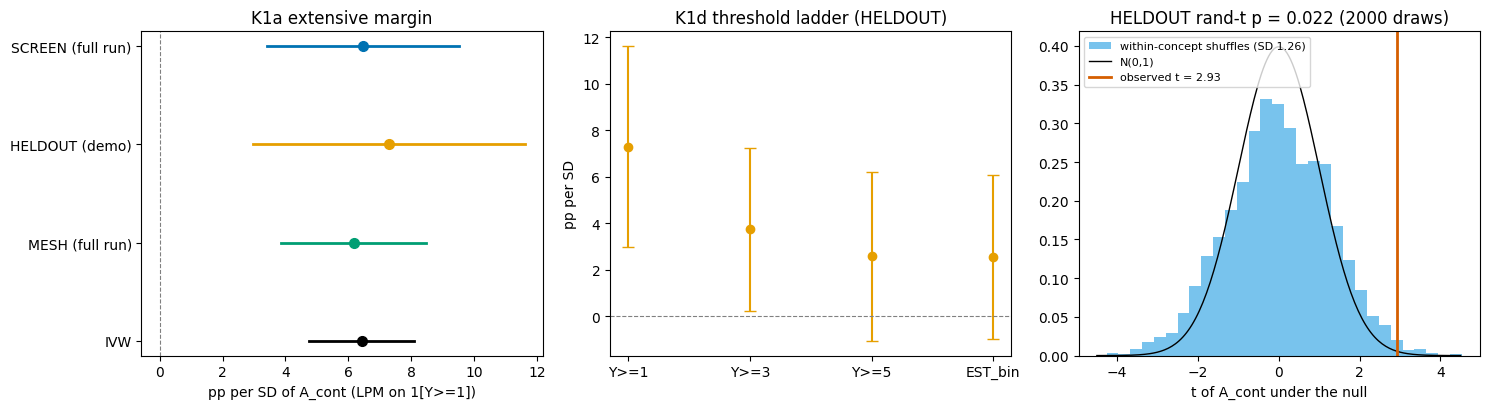

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
# (a) per-fold + IVW extensive margin
lab, est, lo, hi, col = [], [], [], [], []
for f, c in (("SCREEN", "#0072B2"), ("HELDOUT", "#E69F00"), ("MESH", "#009E73")):
    if f == "HELDOUT":
        r = per_h["K1a_LPM"]; lab.append("HELDOUT (demo)"); est.append(r["pp_per_sd"]); lo.append(r["ci_pp_per_sd"][0]); hi.append(r["ci_pp_per_sd"][1])
    else:
        r = ref_fold[(f, "K1a_LPM")]; lab.append(f"{f} (full run)"); est.append(r["estimate"]); lo.append(r["ci_lo"]); hi.append(r["ci_hi"])
    col.append(c)
lab.append("IVW"); est.append(e["est"]); lo.append(e["ci"][0]); hi.append(e["ci"][1]); col.append("#000000")
y = np.arange(len(lab))[::-1]
for yy, m, l, h_, c in zip(y, est, lo, hi, col):
    ax[0].plot([l, h_], [yy, yy], color=c, lw=2); ax[0].plot(m, yy, "o", color=c, ms=7)
ax[0].axvline(0, color="grey", lw=0.8, ls="--"); ax[0].set_yticks(y); ax[0].set_yticklabels(lab)
ax[0].set_xlabel("pp per SD of A_cont (LPM on 1[Y>=1])"); ax[0].set_title("K1a extensive margin")
# (b) held-out ladder
lad = per_h["ladder"]
names = list(lad)
ax[1].errorbar(range(len(names)), [lad[n]["pp_per_sd"] for n in names],
               yerr=[[lad[n]["pp_per_sd"] - lad[n]["ci_pp_per_sd"][0] for n in names],
                     [lad[n]["ci_pp_per_sd"][1] - lad[n]["pp_per_sd"] for n in names]], fmt="o", color="#E69F00", capsize=4)
ax[1].axhline(0, color="grey", lw=0.8, ls="--"); ax[1].set_xticks(range(len(names)))
ax[1].set_xticklabels(["Y>=1", "Y>=3", "Y>=5", "EST_bin"]); ax[1].set_ylabel("pp per SD")
ax[1].set_title("K1d threshold ladder (HELDOUT)")
# (c) randomization null of the PPML t
dd = pd.read_csv(out / "inference_draws.csv")
ts = dd["HELDOUT_cnt_plain_t"].dropna().to_numpy()
t_obs = summ["rows"]["HELDOUT.coprimary_A_count"]["t_obs"]
ax[2].hist(ts, bins=30, density=True, color="#56B4E9", alpha=0.8, label=f"within-concept shuffles (SD {ts.std():.2f})")
xx = np.linspace(-4.5, 4.5, 200); ax[2].plot(xx, stats.norm.pdf(xx), color="k", lw=1, label="N(0,1)")
ax[2].axvline(t_obs, color="#D55E00", lw=2, label=f"observed t = {t_obs:.2f}")
ax[2].set_title(f"HELDOUT rand-t p = {summ['rows']['HELDOUT.coprimary_A_count']['p_rand_t']:.3f} ({len(ts)} draws)")
ax[2].set_xlabel("t of A_cont under the null"); ax[2].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()